# Football Matches 2024/25 — Exploratory Data Analysis

A focused EDA notebook for understanding scoring patterns, home advantage, team performance, and competition-level differences across the 2024/25 football season.

## Overview and Goals

This notebook explores match-level football data across major European competitions. The goal is to turn raw match results into clear, reusable insights that can support football analytics, dashboarding, and future modeling work.

The notebook covers:

- Dataset health, schema coverage, missing values, and duplicate checks
- Match outcomes, scoring patterns, BTTS, and Over 2.5 goal rates
- Home advantage and competition-level differences
- Season-aware monthly trends from August to May
- Team attacking and defensive profiles using per-match rates
- Scoreline, referee, clean-sheet, and half-time comeback patterns
- Final takeaways and practical next steps


# Config and Imports

In [1]:
import warnings
from calendar import month_name
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter

RANDOM_SEED = 42
DATA_FILE = "football_matches_2024_2025.csv"

DATA_PATH_CANDIDATES = [
    Path("/kaggle/input/football-matches-20242025-top-5-leagues") / DATA_FILE,
    Path("../input/football-matches-20242025-top-5-leagues") / DATA_FILE,
    Path("data/raw") / DATA_FILE,
    Path("data") / DATA_FILE,
    Path(DATA_FILE),
]

sns.set_theme(style="whitegrid", palette="Set2")
PLOT_PALETTE = sns.color_palette("Set2")
PRIMARY_COLOR = PLOT_PALETTE[0]
SECONDARY_COLOR = PLOT_PALETTE[1]
ACCENT_COLOR = PLOT_PALETTE[2]
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


def resolve_data_path(candidates, filename=DATA_FILE):
    """Resolve the dataset path for Kaggle and local runs."""
    for path in candidates:
        if Path(path).exists():
            return Path(path)

    for root in [Path("/kaggle/input"), Path("../input"), Path(".")]:
        if root.exists():
            matches = sorted(root.rglob(filename))
            if matches:
                return matches[0]

    searched = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(
        f"Could not find {filename}.\n"
        "On Kaggle, attach the dataset from the notebook Data panel.\n"
        "For local runs, place the CSV under data/raw/.\n\n"
        f"Searched:\n{searched}"
    )


def wrap_labels(ax, width=16):
    """Wrap long x-axis tick labels for cleaner charts."""
    new_labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        new_labels.append("\n".join([text[i : i + width] for i in range(0, len(text), width)]))
    ax.set_xticklabels(new_labels, rotation=0)


def format_rate(value):
    """Format a decimal share as a percentage string."""
    return f"{value:.1%}"


# Data Loading

In [2]:
data_path = resolve_data_path(DATA_PATH_CANDIDATES)

df = pd.read_csv(data_path)

print(f"Loaded dataset from: {data_path}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")


Loaded dataset from: data/raw/football_matches_2024_2025.csv
Shape: 1,941 rows x 23 columns


# Dataset Overview

In [3]:
print("Shape:", df.shape)

display(df.head())

print("\nDataset info:")
df.info()

print("\nNumeric summary:")
display(df.describe(include="number").T)

overview = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "duplicate_rows",
            "duplicate_match_id",
            "competitions",
            "home_teams",
            "away_teams",
        ],
        "value": [
            len(df),
            df.shape[1],
            int(df.duplicated().sum()),
            int(df["match_id"].duplicated().sum()) if "match_id" in df.columns else "not_available",
            df["competition_name"].nunique() if "competition_name" in df.columns else "not_available",
            df["home_team"].nunique() if "home_team" in df.columns else "not_available",
            df["away_team"].nunique() if "away_team" in df.columns else "not_available",
        ],
    }
)

display(overview)


Shape: (1941, 23)


,competition_code,competition_name,season,match_id,matchday,stage,status,date_utc,referee,home_team_id,home_team,away_team_id,away_team,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,match_outcome,home_points,away_points,referee_id
0,PL,Premier League,2024/2025,497410,1,REGULAR_SEASON,FINISHED,2024-08-16 19:00:00+00:00,Robert Jones,66,Manchester United FC,63,Fulham FC,1,0,0,0,1,1,Home Win,3,0,1
1,PL,Premier League,2024/2025,497411,1,REGULAR_SEASON,FINISHED,2024-08-17 11:30:00+00:00,Tim Robinson,349,Ipswich Town FC,64,Liverpool FC,0,2,0,0,-2,2,Away Win,0,3,2
2,PL,Premier League,2024/2025,497412,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Jarred Gillett,57,Arsenal FC,76,Wolverhampton Wanderers FC,2,0,1,0,2,2,Home Win,3,0,3
3,PL,Premier League,2024/2025,497413,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Simon Hooper,62,Everton FC,397,Brighton & Hove Albion FC,0,3,0,1,-3,3,Away Win,0,3,4
4,PL,Premier League,2024/2025,497414,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Craig Pawson,67,Newcastle United FC,340,Southampton FC,1,0,1,0,1,1,Home Win,3,0,5



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   competition_code  1941 non-null   object
 1   competition_name  1941 non-null   object
 2   season            1941 non-null   object
 3   match_id          1941 non-null   int64 
 4   matchday          1941 non-null   int64 
 5   stage             1941 non-null   object
 6   status            1941 non-null   object
 7   date_utc          1941 non-null   object
 8   referee           1941 non-null   object
 9   home_team_id      1941 non-null   int64 
 10  home_team         1941 non-null   object
 11  away_team_id      1941 non-null   int64 
 12  away_team         1941 non-null   object
 13  fulltime_home     1941 non-null   int64 
 14  fulltime_away     1941 non-null   int64 
 15  halftime_home     1941 non-null   int64 
 16  halftime_away     1941 non-null   int64 
 17 

,count,mean,std,min,25%,50%,75%,max
match_id,1941.0,502366.762494,7461.271565,497410.0,498056.0,498897.0,503126.0,524120.0
matchday,1941.0,17.338485,11.056850,0.0,7.0,17.0,27.0,38.0
home_team_id,1941.0,483.205564,1170.086272,2.0,67.0,109.0,522.0,7509.0
away_team_id,1941.0,482.991242,1170.116895,2.0,67.0,109.0,522.0,7509.0
fulltime_home,1941.0,1.535806,1.322829,0.0,1.0,1.0,2.0,9.0
fulltime_away,1941.0,1.340031,1.205567,0.0,0.0,1.0,2.0,7.0
halftime_home,1941.0,0.699639,0.860319,0.0,0.0,1.0,1.0,6.0
halftime_away,1941.0,0.588357,0.790438,0.0,0.0,0.0,1.0,5.0
goal_difference,1941.0,0.195775,1.880667,-6.0,-1.0,0.0,1.0,8.0
total_goals,1941.0,2.875837,1.693997,0.0,2.0,3.0,4.0,11.0


,metric,value
0,rows,1941
1,columns,23
2,duplicate_rows,0
3,duplicate_match_id,0
4,competitions,6
5,home_teams,110
6,away_teams,110


# Clean Data

In [4]:
print("Missing values per column before cleaning:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_values"))

# Fill missing referee names with a stable placeholder when needed.
if "referee" in df.columns:
    df["referee"] = df["referee"].fillna("Unknown")

# Keep only finished matches with full-time scores.
df = df.dropna(subset=["fulltime_home", "fulltime_away"]).copy()

# Parse dates once and sort chronologically.
df["date"] = pd.to_datetime(df["date_utc"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

# Remove exact duplicate rows.
df = df.drop_duplicates().reset_index(drop=True)

print("\nAfter cleaning:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_values"))
print("Shape:", df.shape)

if "match_id" in df.columns:
    print("Duplicate match_id values:", int(df["match_id"].duplicated().sum()))

print("Date range:", df["date"].min(), "to", df["date"].max())


Missing values per column before cleaning:


,missing_values
competition_code,0
competition_name,0
season,0
match_id,0
matchday,0
stage,0
status,0
date_utc,0
referee,0
home_team_id,0



After cleaning:


,missing_values
competition_code,0
competition_name,0
season,0
match_id,0
matchday,0
stage,0
status,0
date_utc,0
referee,0
home_team_id,0


Shape: (1941, 24)
Duplicate match_id values: 0
Date range: 2024-08-15 17:00:00+00:00 to 2025-05-31 19:00:00+00:00


# Feature Engineering

In [5]:
# Goal metrics
df["total_goals"] = df["fulltime_home"] + df["fulltime_away"]
df["goal_difference"] = df["fulltime_home"] - df["fulltime_away"]

# Backward-compatible aliases used in existing charts.
df["TotalGoals"] = df["total_goals"]
df["GoalDiff"] = df["goal_difference"]

# Points
df["home_points"] = np.where(
    df["fulltime_home"] > df["fulltime_away"],
    3,
    np.where(df["fulltime_home"] == df["fulltime_away"], 1, 0),
)
df["away_points"] = np.where(
    df["fulltime_away"] > df["fulltime_home"],
    3,
    np.where(df["fulltime_home"] == df["fulltime_away"], 1, 0),
)

# Outcome flags
df["is_home_win"] = (df["fulltime_home"] > df["fulltime_away"]).astype(int)
df["is_draw"] = (df["fulltime_home"] == df["fulltime_away"]).astype(int)
df["is_away_win"] = (df["fulltime_away"] > df["fulltime_home"]).astype(int)

# Quick scoring indicators
df["BTTS"] = ((df["fulltime_home"] > 0) & (df["fulltime_away"] > 0)).astype(int)
df["Over2_5"] = (df["total_goals"] > 2.5).astype(int)

# Time features using football-season order instead of calendar-year order.
df["month"] = df["date"].dt.month_name()
df["weekday"] = df["date"].dt.day_name()

season_month_order = [
    "August",
    "September",
    "October",
    "November",
    "December",
    "January",
    "February",
    "March",
    "April",
    "May",
]
months = [month for month in season_month_order if month in set(df["month"])]
df["month"] = pd.Categorical(df["month"], categories=season_month_order, ordered=True)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["weekday"] = pd.Categorical(df["weekday"], categories=weekday_order, ordered=True)

# Labels
df["scoreline"] = df["fulltime_home"].astype(str) + "-" + df["fulltime_away"].astype(str)

# Clean sheets
df["home_cs"] = (df["fulltime_away"] == 0).astype(int)
df["away_cs"] = (df["fulltime_home"] == 0).astype(int)


## Core KPI Summary

This section creates a compact decision-ready summary before moving into detailed visuals. These metrics help frame the rest of the EDA.

In [6]:
core_kpis = pd.DataFrame(
    {
        "metric": [
            "Matches",
            "Competitions",
            "Teams",
            "Date range",
            "Average goals per match",
            "Home win rate",
            "Draw rate",
            "Away win rate",
            "BTTS rate",
            "Over 2.5 goals rate",
        ],
        "value": [
            f"{len(df):,}",
            df["competition_name"].nunique(),
            pd.concat([df["home_team"], df["away_team"]]).nunique(),
            f"{df['date'].min().date()} to {df['date'].max().date()}",
            f"{df['total_goals'].mean():.2f}",
            format_rate(df["is_home_win"].mean()),
            format_rate(df["is_draw"].mean()),
            format_rate(df["is_away_win"].mean()),
            format_rate(df["BTTS"].mean()),
            format_rate(df["Over2_5"].mean()),
        ],
    }
)

display(core_kpis)

competition_summary = (
    df.groupby("competition_name")
    .agg(
        matches=("match_id", "count"),
        avg_goals=("total_goals", "mean"),
        btts_rate=("BTTS", "mean"),
        over_2_5_rate=("Over2_5", "mean"),
        home_win_rate=("is_home_win", "mean"),
    )
    .sort_values("avg_goals", ascending=False)
)

display(
    competition_summary.style.format(
        {
            "avg_goals": "{:.2f}",
            "btts_rate": "{:.1%}",
            "over_2_5_rate": "{:.1%}",
            "home_win_rate": "{:.1%}",
        }
    )
)


,metric,value
0,Matches,"1,941"
1,Competitions,6
2,Teams,110
3,Date range,2024-08-15 to 2025-05-31
4,Average goals per match,2.88
5,Home win rate,42.9%
6,Draw rate,23.9%
7,Away win rate,33.3%
8,BTTS rate,55.1%
9,Over 2.5 goals rate,54.6%


,matches,avg_goals,btts_rate,over_2_5_rate,home_win_rate
competition_name,,,,,
UEFA Champions League,189,3.33,54.0%,65.6%,50.8%
Bundesliga,306,3.13,56.9%,59.8%,38.6%
Ligue 1,306,2.98,56.9%,55.6%,46.7%
Premier League,380,2.93,57.4%,56.6%,40.8%
La Liga,380,2.62,54.2%,48.7%,44.5%
Serie A,380,2.56,51.6%,48.2%,39.7%


# EDA


## Matches per Competition

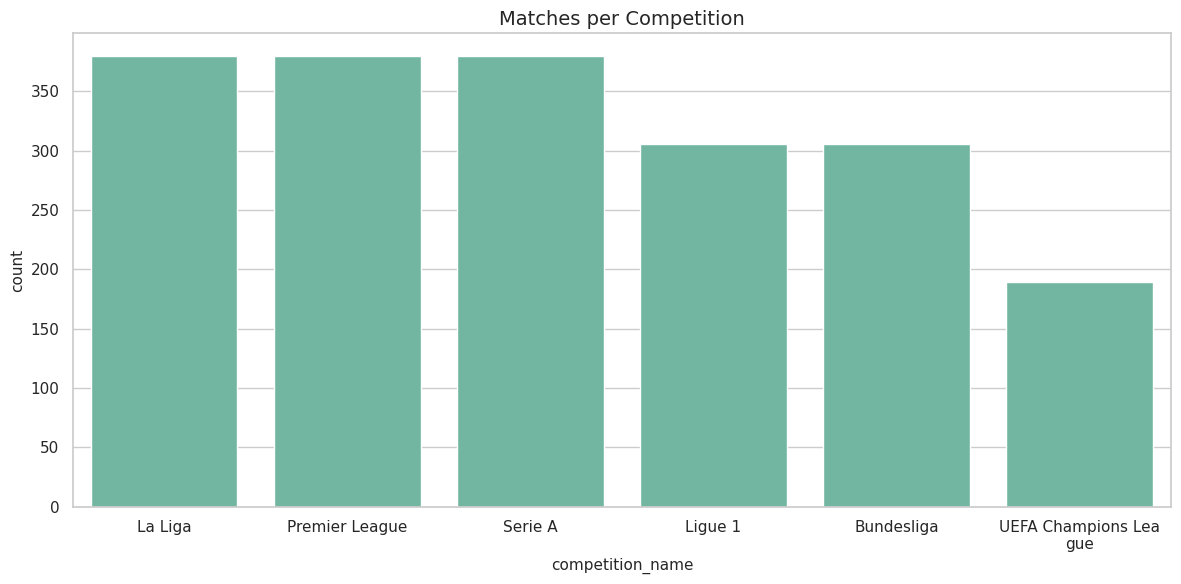

In [7]:
order_comp_count = df["competition_name"].value_counts().index
ax = sns.countplot(data=df, x="competition_name", order=order_comp_count, color=PRIMARY_COLOR)
plt.title("Matches per Competition")
plt.xticks(rotation=0)
wrap_labels(ax, width=18)
plt.tight_layout()
plt.show()


## Outcomes (overall)

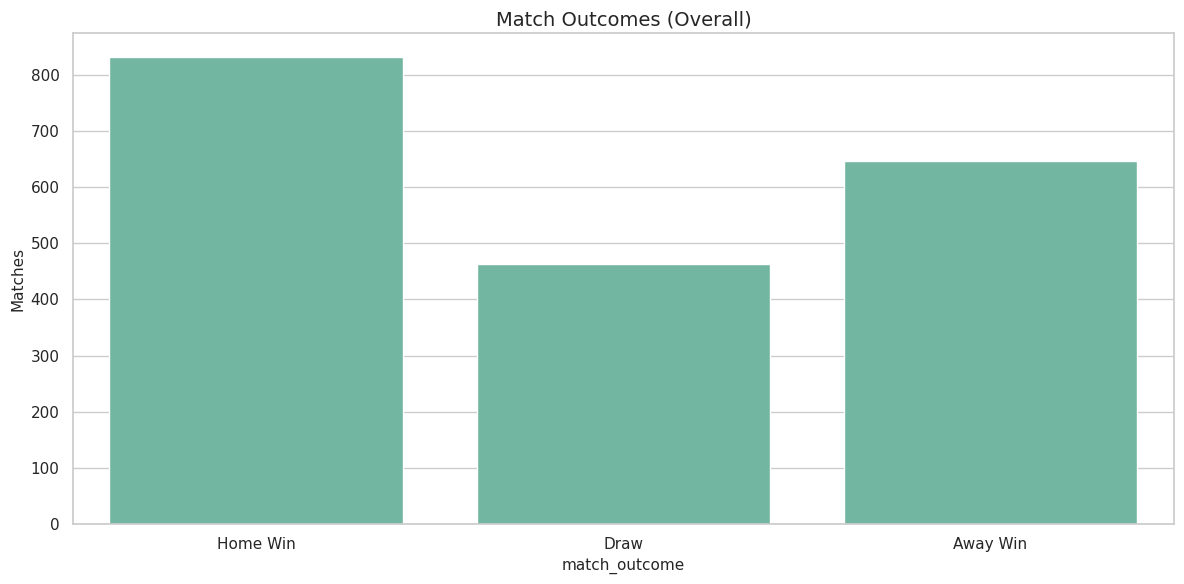

In [8]:
outcome_order = [c for c in ["Home Win", "Draw", "Away Win"] if c in df["match_outcome"].unique()]
ax = sns.countplot(data=df, x="match_outcome", order=outcome_order, color=PRIMARY_COLOR)
plt.title("Match Outcomes (Overall)"); plt.ylabel("Matches")
plt.tight_layout()
plt.show()


## Goals Distribution

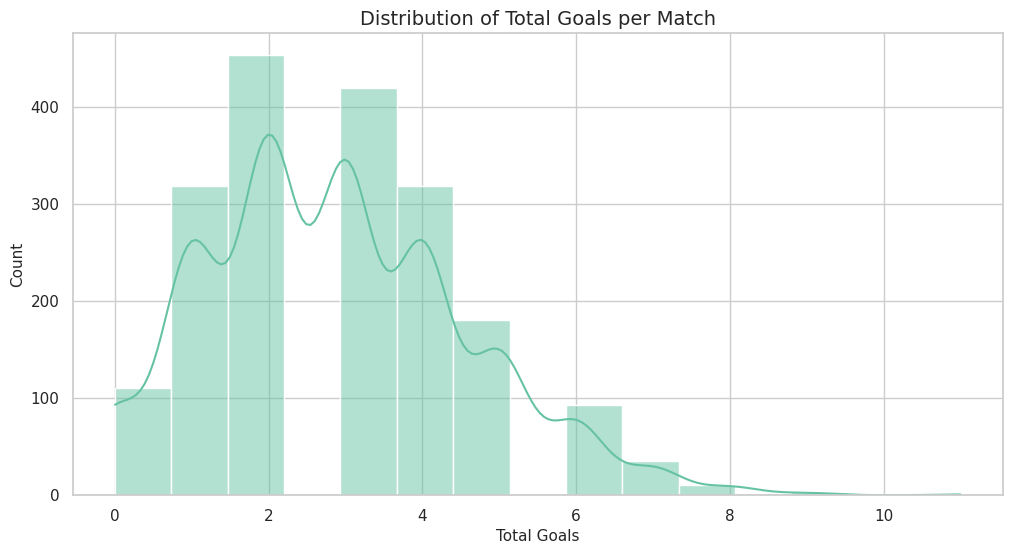

In [9]:
sns.histplot(df["TotalGoals"], bins=15, kde=True, color=PRIMARY_COLOR)
plt.title("Distribution of Total Goals per Match"); plt.xlabel("Total Goals")
plt.show()

## FacetGrid Total Goals Distribution — per Competition

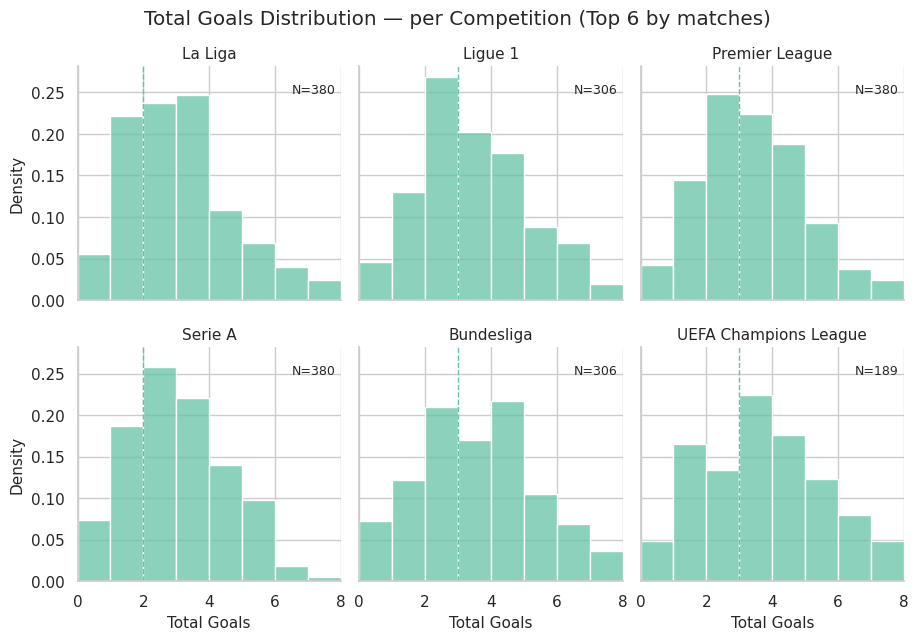

In [10]:
comp_counts = df["competition_name"].value_counts()
TOPN = 6
top_comps = comp_counts.head(TOPN).index
sub = df[df["competition_name"].isin(top_comps)].copy()

# FacetGrid with unified bins/axes + median line + N
xmax = int(np.quantile(df["TotalGoals"], 0.99)) + 1
bins = np.arange(0, max(7, xmax)+1)

def facet_hist(data, color=None, **kws):
    ax = plt.gca()
    plot_color = color if color is not None else PRIMARY_COLOR
    sns.histplot(data=data, x="TotalGoals", bins=bins, stat="density", ax=ax, color=plot_color)
    med = data["TotalGoals"].median()
    ax.axvline(med, ls="--", lw=1)
    ax.text(0.98, 0.9, f"N={len(data)}", transform=ax.transAxes, ha="right", va="center", fontsize=9)

g = sns.FacetGrid(sub, col="competition_name", col_wrap=3, sharex=True, sharey=True, height=3.1)
g.map_dataframe(facet_hist)
g.set_titles("{col_name}")
g.set_xlabels("Total Goals"); g.set_ylabels("Density")
g.set(xlim=(0, bins.max()))
plt.suptitle("Total Goals Distribution — per Competition (Top 6 by matches)", y=1.03)
plt.show()


## Total Goals by Competition

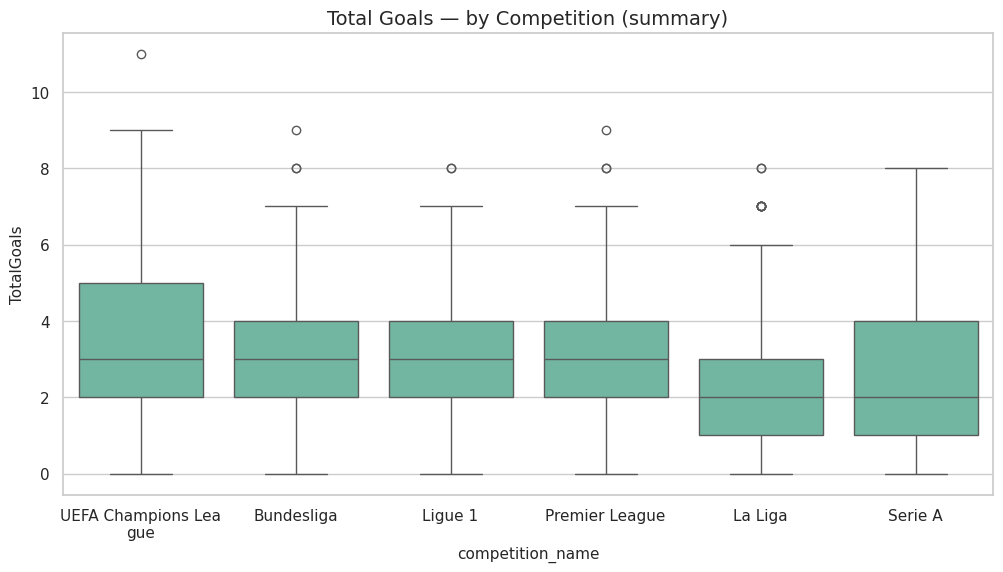

In [11]:
order_comp = df.groupby("competition_name")["TotalGoals"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="competition_name", y="TotalGoals", order=order_comp, color=PRIMARY_COLOR)
plt.xticks(rotation=45); wrap_labels(plt.gca(), width=18)
plt.title("Total Goals — by Competition (summary)")
plt.show()

## Avg Goals & BTTS (side-by-side)

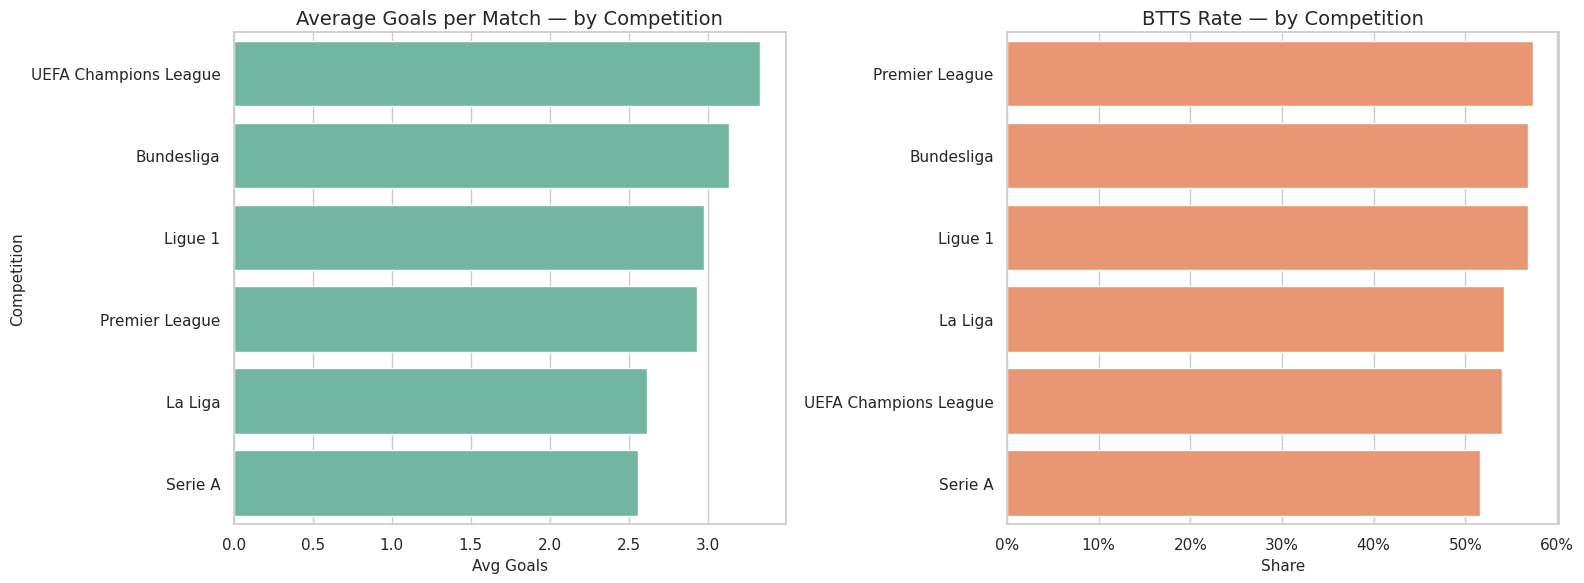

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

avg_goals = df.groupby("competition_name")["TotalGoals"].mean().sort_values(ascending=False)
sns.barplot(x=avg_goals.values, y=avg_goals.index, ax=axes[0], color=PRIMARY_COLOR)
axes[0].set_title("Average Goals per Match — by Competition")
axes[0].set_xlabel("Avg Goals"); axes[0].set_ylabel("Competition")

btts_rate = df.groupby("competition_name")["BTTS"].mean().sort_values(ascending=False)
sns.barplot(x=btts_rate.values, y=btts_rate.index, ax=axes[1], color=SECONDARY_COLOR)
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("BTTS Rate — by Competition")
axes[1].set_xlabel("Share"); axes[1].set_ylabel("")

plt.tight_layout(); plt.show()

## Home Advantage (Home win rate)

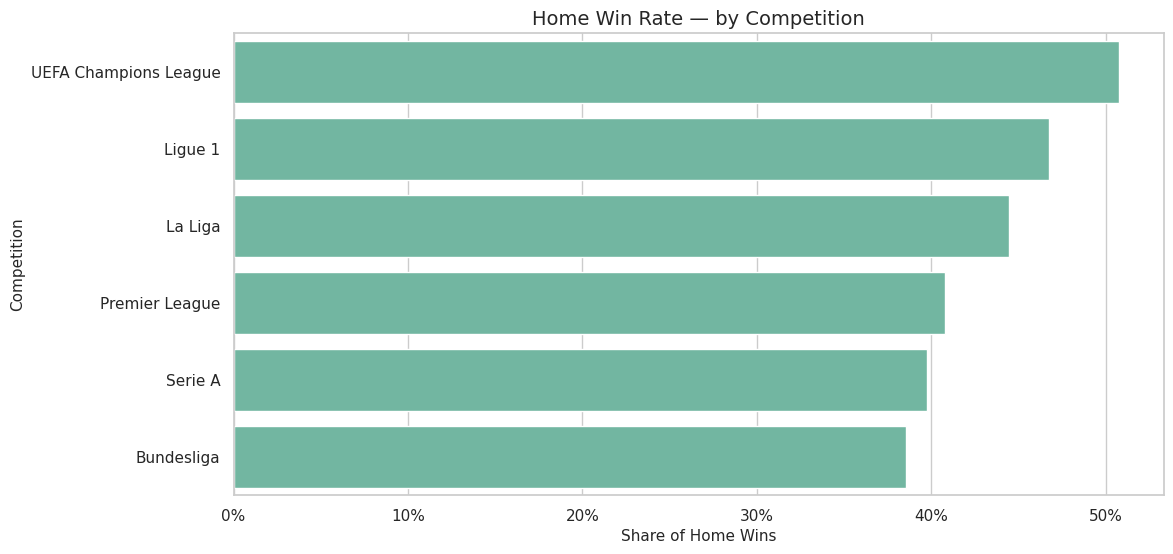

In [13]:
home_adv = df.groupby("competition_name")["is_home_win"].mean().sort_values(ascending=False)
ax = sns.barplot(x=home_adv.values, y=home_adv.index, color=PRIMARY_COLOR)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.title("Home Win Rate — by Competition"); plt.xlabel("Share of Home Wins"); plt.ylabel("Competition")
plt.show()

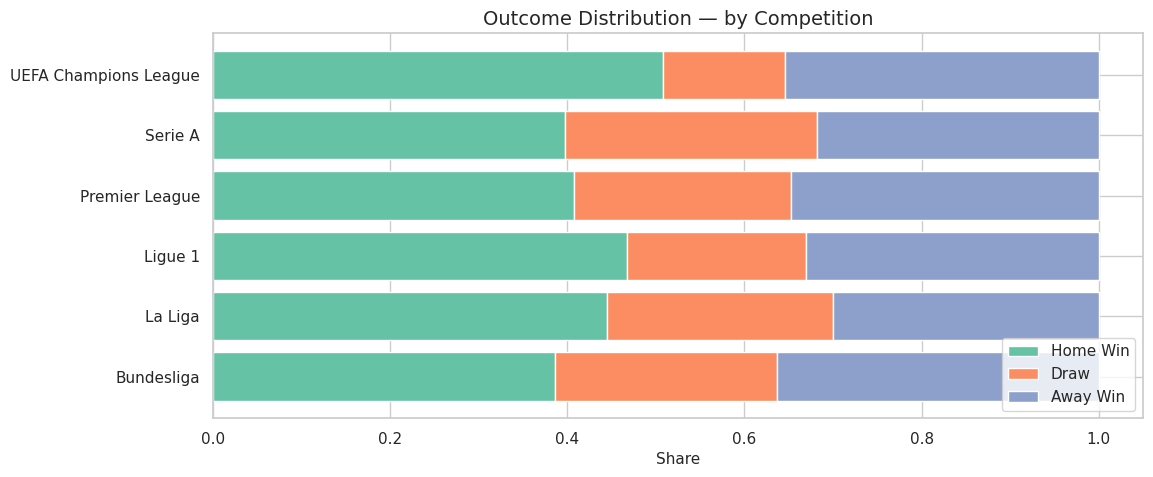

In [14]:
out = pd.crosstab(df["competition_name"], df["match_outcome"], normalize="index").fillna(0)
order_cols = [c for c in ["Home Win","Draw","Away Win"] if c in out.columns]
if order_cols:
    out = out[order_cols]

plt.figure(figsize=(12, max(5, 0.4*len(out))))
bottom = np.zeros(len(out))
for col in out.columns:
    plt.barh(out.index, out[col].values, left=bottom, label=col)
    bottom += out[col].values
plt.title("Outcome Distribution — by Competition")
plt.xlabel("Share"); plt.legend(loc="lower right")
plt.show()

## Matches over Time by Season Month

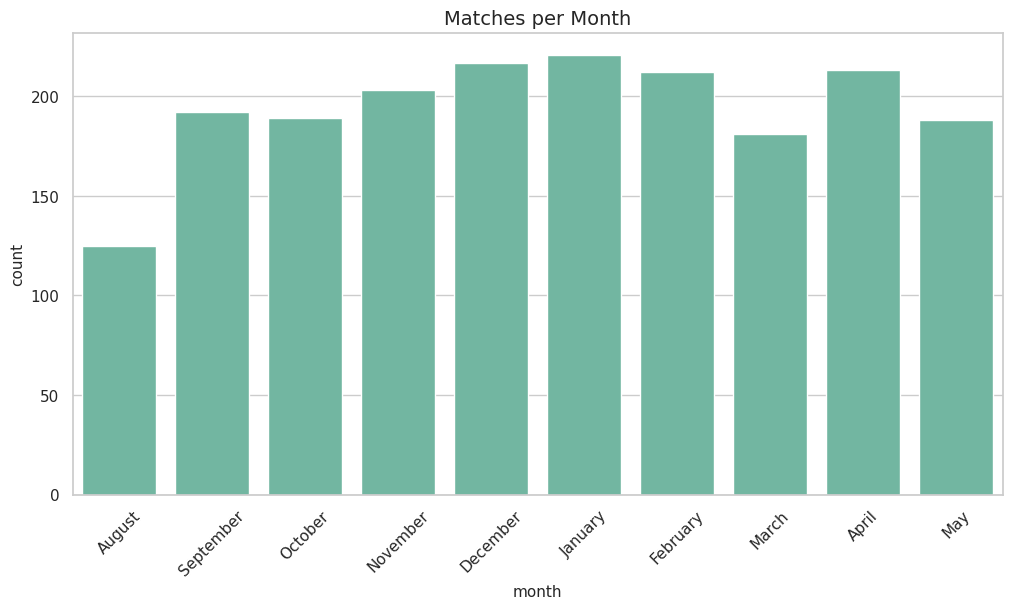

In [15]:
ax = sns.countplot(data=df, x="month", order=months, color=PRIMARY_COLOR)
plt.title("Matches per Month"); plt.xticks(rotation=45)
plt.show()

## Weekly Matches & Avg Goals (twin axis)

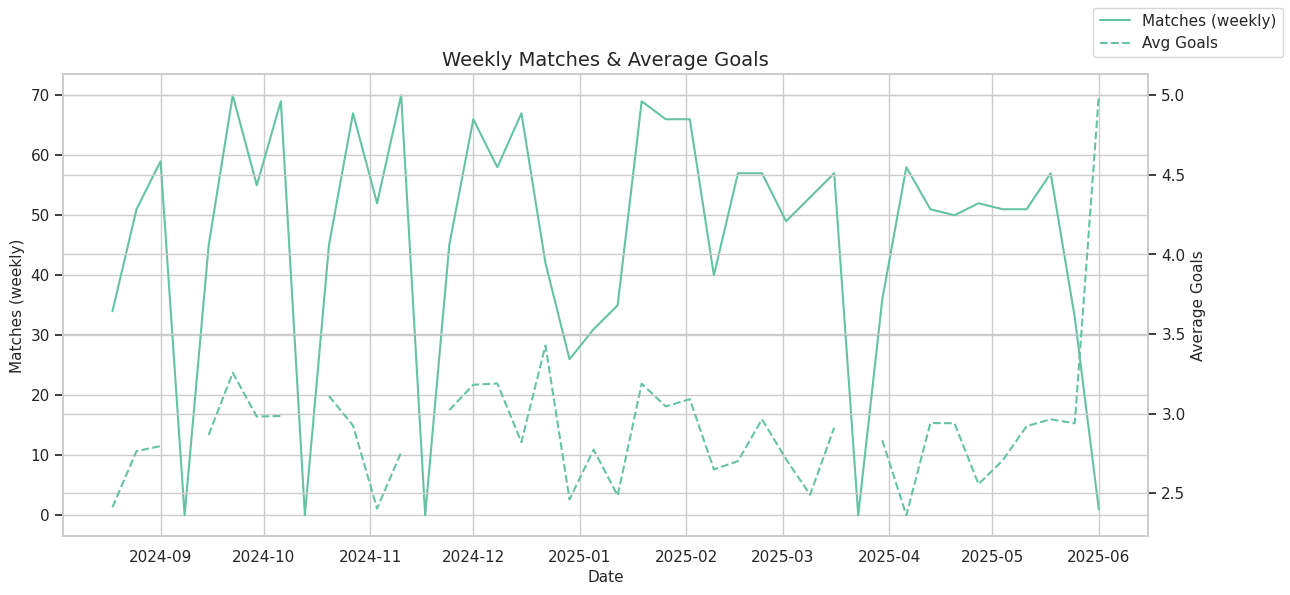

In [16]:
weekly = df.resample("W", on="date").agg(
    matches=("match_outcome","count"),
    avg_goals=("TotalGoals","mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(14,6)); ax2 = ax1.twinx()
ax1.plot(weekly["date"], weekly["matches"], label="Matches (weekly)")
ax2.plot(weekly["date"], weekly["avg_goals"], label="Avg Goals", linestyle="--")
ax1.set_title("Weekly Matches & Average Goals"); ax1.set_xlabel("Date")
ax1.set_ylabel("Matches (weekly)"); ax2.set_ylabel("Average Goals")
fig.legend(loc="upper right"); plt.show()


## Over 2.5 Goals Rate by Season Month

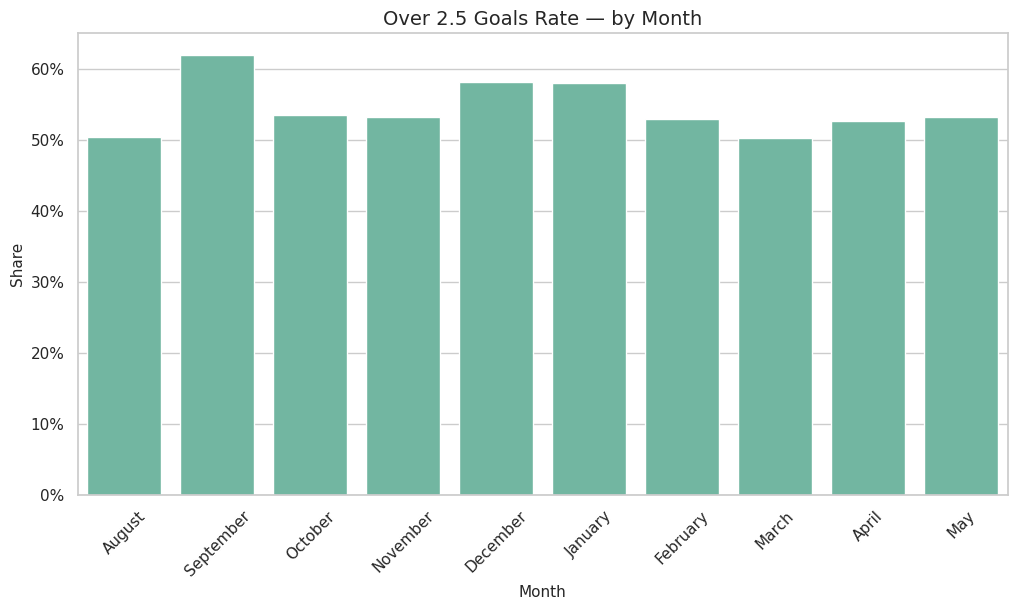

In [17]:
over_rate_month = df.groupby("month")["Over2_5"].mean().reindex(months)
ax = sns.barplot(x=over_rate_month.index, y=over_rate_month.values, color=PRIMARY_COLOR)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title("Over 2.5 Goals Rate — by Month"); plt.xlabel("Month"); plt.ylabel("Share")
plt.xticks(rotation=45); plt.show()

## BTTS Rate by Season Month

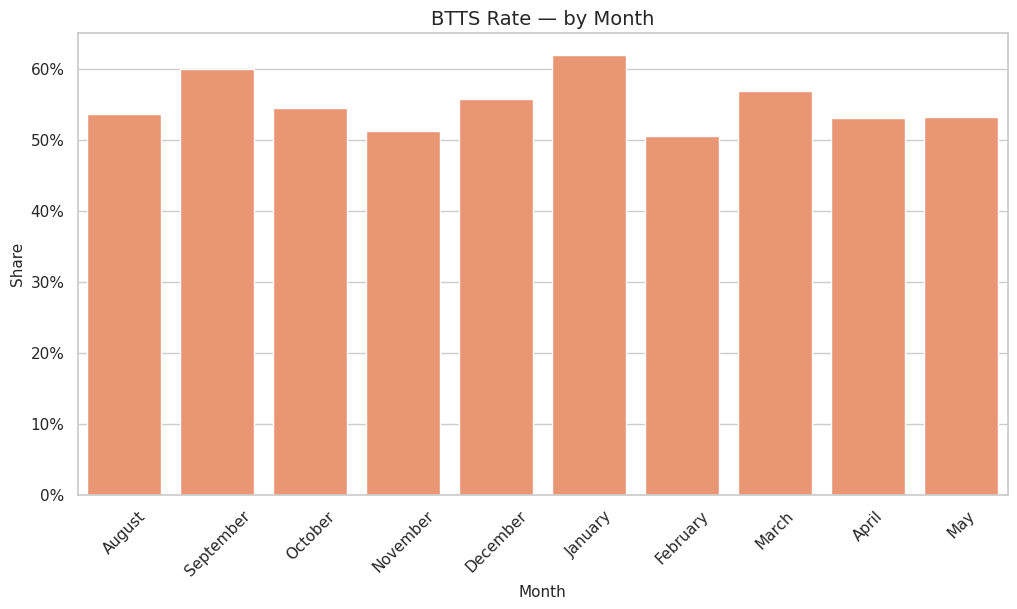

In [18]:
btts_rate_month = df.groupby("month")["BTTS"].mean().reindex(months)
ax = sns.barplot(x=btts_rate_month.index, y=btts_rate_month.values, color=SECONDARY_COLOR)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title("BTTS Rate — by Month"); plt.xlabel("Month"); plt.ylabel("Share")
plt.xticks(rotation=45); plt.show()


## Outcome Share by Season Month

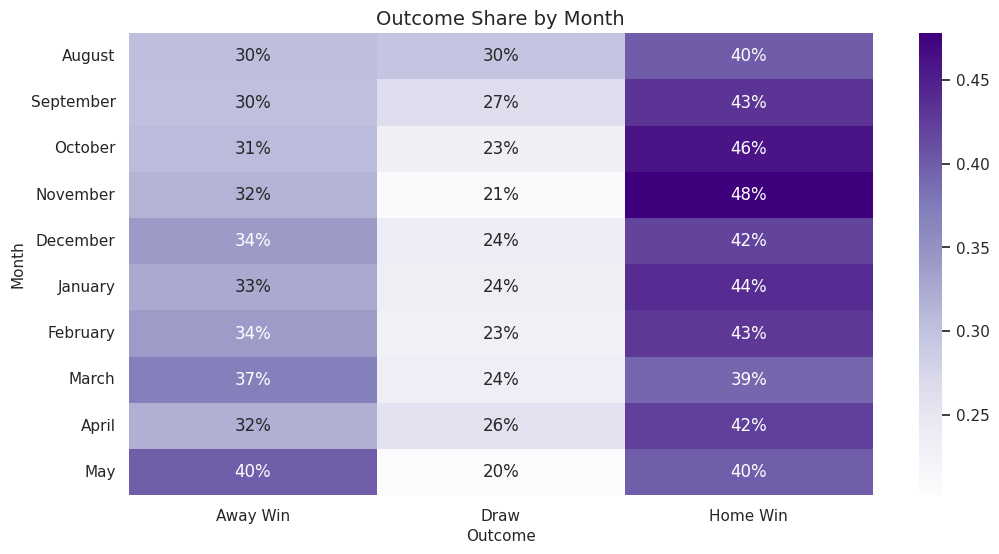

In [19]:
tab_m = pd.crosstab(df["month"], df["match_outcome"], normalize="index").fillna(0).reindex(months)
sns.heatmap(tab_m, annot=True, fmt=".0%", cmap="Purples")
plt.title("Outcome Share by Month"); plt.xlabel("Outcome"); plt.ylabel("Month")
plt.show()


## Rolling 4-week Outcome Shares

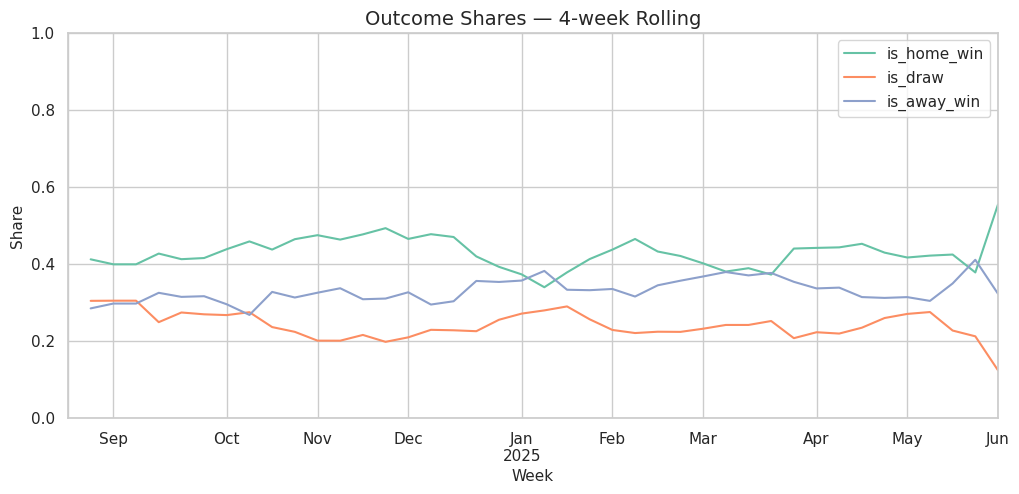

In [20]:
wk = df.resample("W", on="date")[["is_home_win","is_draw","is_away_win"]].mean()
wk_roll = wk.rolling(4, min_periods=2).mean()
wk_roll.plot(figsize=(12,5))
plt.ylim(0,1); plt.title("Outcome Shares — 4-week Rolling"); plt.xlabel("Week"); plt.ylabel("Share")
plt.show()


## Team Attacking and Defensive Profile per Match

Total goals can be misleading when teams play different numbers of matches. This section uses per-match attacking and defensive rates with a minimum match threshold.

,matches,goals_for,goals_against,goal_difference,goals_for_per_match,goals_against_per_match,goal_difference_per_match
team,,,,,,,
FC Barcelona,52,145,63,82,2.79,1.21,1.58
FC Bayern München,48,130,50,80,2.71,1.04,1.67
Paris Saint-Germain FC,51,134,51,83,2.63,1.00,1.63
Liverpool FC,48,105,51,54,2.19,1.06,1.12
Olympique de Marseille,34,74,47,27,2.18,1.38,0.79
Real Madrid CF,52,111,62,49,2.13,1.19,0.94
Borussia Dortmund,48,102,70,32,2.12,1.46,0.67
Atalanta BC,48,100,48,52,2.08,1.00,1.08
Eintracht Frankfurt,34,68,46,22,2.00,1.35,0.65


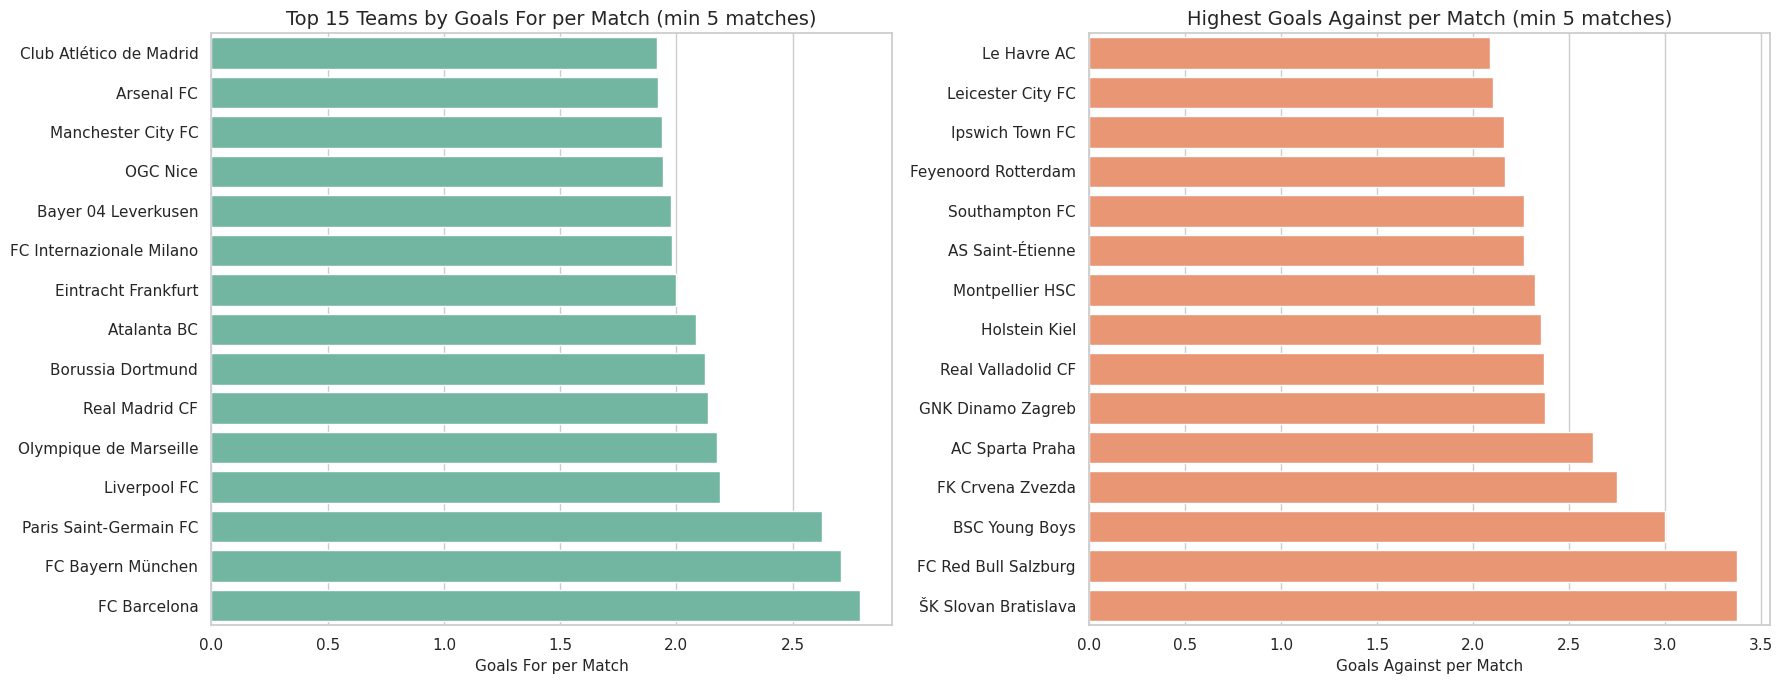

In [21]:
MIN_TEAM_MATCHES = 5

home_profile = (
    df.groupby("home_team")
    .agg(
        home_matches=("match_id", "count"),
        goals_for_home=("fulltime_home", "sum"),
        goals_against_home=("fulltime_away", "sum"),
    )
    .rename_axis("team")
)

away_profile = (
    df.groupby("away_team")
    .agg(
        away_matches=("match_id", "count"),
        goals_for_away=("fulltime_away", "sum"),
        goals_against_away=("fulltime_home", "sum"),
    )
    .rename_axis("team")
)

team_goal_profile = home_profile.join(away_profile, how="outer").fillna(0)

team_goal_profile["matches"] = (
    team_goal_profile["home_matches"] + team_goal_profile["away_matches"]
)
team_goal_profile["goals_for"] = (
    team_goal_profile["goals_for_home"] + team_goal_profile["goals_for_away"]
)
team_goal_profile["goals_against"] = (
    team_goal_profile["goals_against_home"] + team_goal_profile["goals_against_away"]
)
team_goal_profile["goal_difference"] = (
    team_goal_profile["goals_for"] - team_goal_profile["goals_against"]
)
team_goal_profile["goals_for_per_match"] = (
    team_goal_profile["goals_for"] / team_goal_profile["matches"]
)
team_goal_profile["goals_against_per_match"] = (
    team_goal_profile["goals_against"] / team_goal_profile["matches"]
)
team_goal_profile["goal_difference_per_match"] = (
    team_goal_profile["goal_difference"] / team_goal_profile["matches"]
)

team_goal_profile = team_goal_profile.query("matches >= @MIN_TEAM_MATCHES").sort_values(
    "goals_for_per_match", ascending=False
)

display(
    team_goal_profile[
        [
            "matches",
            "goals_for",
            "goals_against",
            "goal_difference",
            "goals_for_per_match",
            "goals_against_per_match",
            "goal_difference_per_match",
        ]
    ]
    .head(15)
    .style.format(
        {
            "matches": "{:.0f}",
            "goals_for": "{:.0f}",
            "goals_against": "{:.0f}",
            "goal_difference": "{:.0f}",
            "goals_for_per_match": "{:.2f}",
            "goals_against_per_match": "{:.2f}",
            "goal_difference_per_match": "{:.2f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_attack = team_goal_profile.head(15).sort_values("goals_for_per_match", ascending=True)
sns.barplot(
    data=top_attack.reset_index(),
    x="goals_for_per_match",
    y="team",
    ax=axes[0],
    color=PRIMARY_COLOR,
)
axes[0].set_title(f"Top 15 Teams by Goals For per Match (min {MIN_TEAM_MATCHES} matches)")
axes[0].set_xlabel("Goals For per Match")
axes[0].set_ylabel("")

top_defensive_risk = team_goal_profile.sort_values("goals_against_per_match", ascending=False).head(15)
top_defensive_risk = top_defensive_risk.sort_values("goals_against_per_match", ascending=True)
sns.barplot(
    data=top_defensive_risk.reset_index(),
    x="goals_against_per_match",
    y="team",
    ax=axes[1],
    color=SECONDARY_COLOR,
)
axes[1].set_title(f"Highest Goals Against per Match (min {MIN_TEAM_MATCHES} matches)")
axes[1].set_xlabel("Goals Against per Match")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## Points per Game (PPG) — Top 15 (min 10 matches)

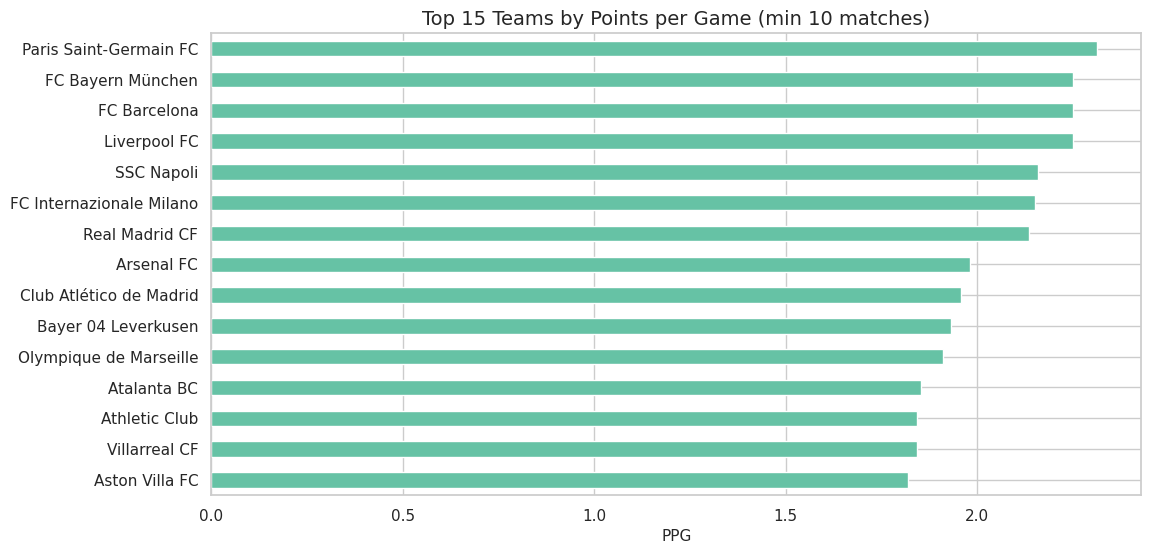

In [22]:
home_part = df[["date","competition_name","home_team","home_points"]].rename(
    columns={"home_team":"team","home_points":"points"})
away_part = df[["date","competition_name","away_team","away_points"]].rename(
    columns={"away_team":"team","away_points":"points"})
team_matches = pd.concat([home_part, away_part], axis=0, ignore_index=True)

ppg = (team_matches.groupby("team")
       .agg(matches=("points","count"), ppg=("points","mean"))
       .sort_values("ppg", ascending=False))

ppg_plot = ppg.query("matches >= 10").head(15).sort_values("ppg", ascending=True)
ppg_plot["ppg"].plot(kind="barh")
plt.title("Top 15 Teams by Points per Game (min 10 matches)"); plt.xlabel("PPG"); plt.ylabel("")
plt.show()


## Home vs Away PPG

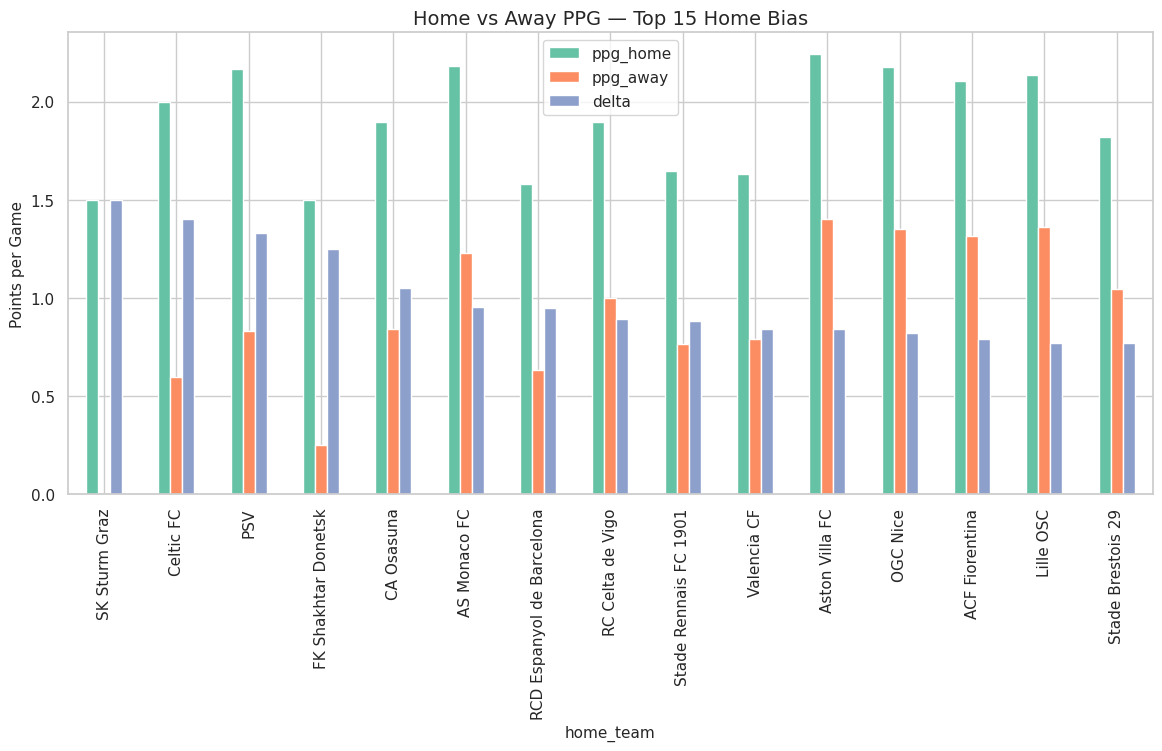

In [23]:
home_ppg = (df.groupby("home_team")["home_points"].agg(["sum","count"]).rename(columns={"sum":"pts","count":"gp"}))
home_ppg["ppg_home"] = home_ppg["pts"] / home_ppg["gp"]

away_ppg = (df.groupby("away_team")["away_points"].agg(["sum","count"]).rename(columns={"sum":"pts","count":"gp"}))
away_ppg["ppg_away"] = away_ppg["pts"] / away_ppg["gp"]

ppg_side = (home_ppg[["ppg_home"]].join(away_ppg[["ppg_away"]], how="outer").fillna(0))
ppg_side["delta"] = ppg_side["ppg_home"] - ppg_side["ppg_away"]

ppg_side.sort_values("delta", ascending=False).head(15)[["ppg_home","ppg_away","delta"]].plot(
    kind="bar", figsize=(14,6), title="Home vs Away PPG — Top 15 Home Bias"
)
plt.ylabel("Points per Game"); plt.show()


## Scoreline Heatmap

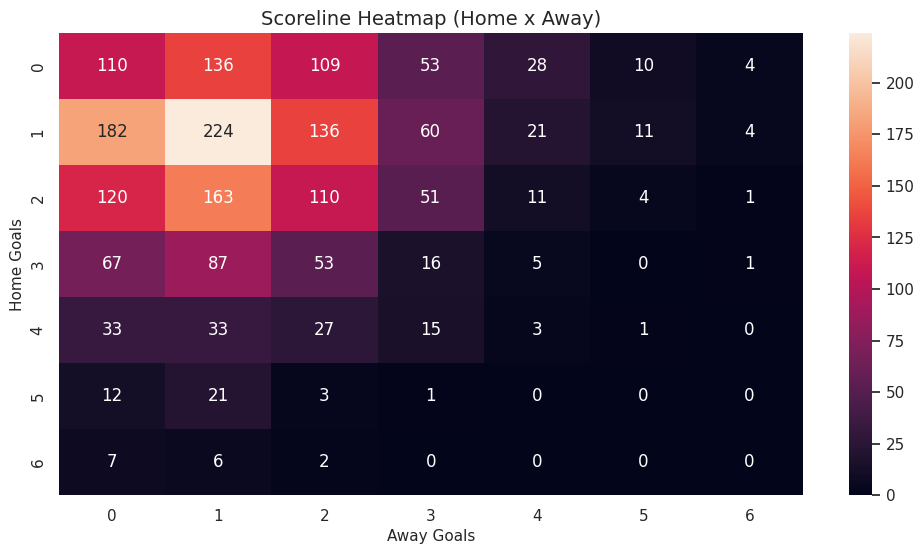

In [24]:
clip = df.copy()
clip["H"] = clip["fulltime_home"].clip(0,6)
clip["A"] = clip["fulltime_away"].clip(0,6)
mat = pd.crosstab(clip["H"], clip["A"])

sns.heatmap(mat, annot=True, fmt="d")
plt.title("Scoreline Heatmap (Home x Away)"); plt.xlabel("Away Goals"); plt.ylabel("Home Goals")
plt.show()


## Top Scorelines

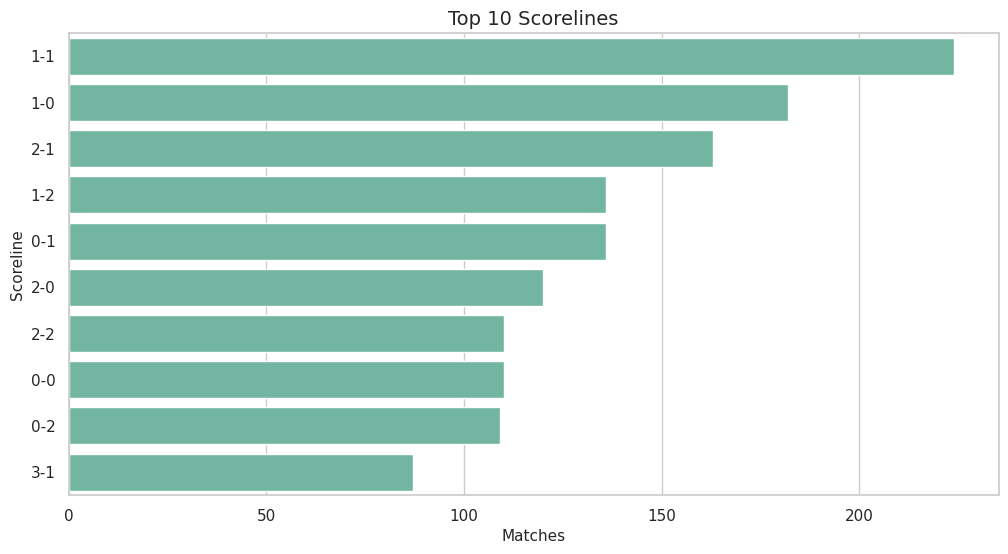

In [25]:
top_scores = df["scoreline"].value_counts().head(10)
sns.barplot(x=top_scores.values, y=top_scores.index, color=PRIMARY_COLOR)
plt.title("Top 10 Scorelines"); plt.xlabel("Matches"); plt.ylabel("Scoreline")
plt.show()

## Matches per Referee + Avg Goals per Referee for Top Refs by Matches

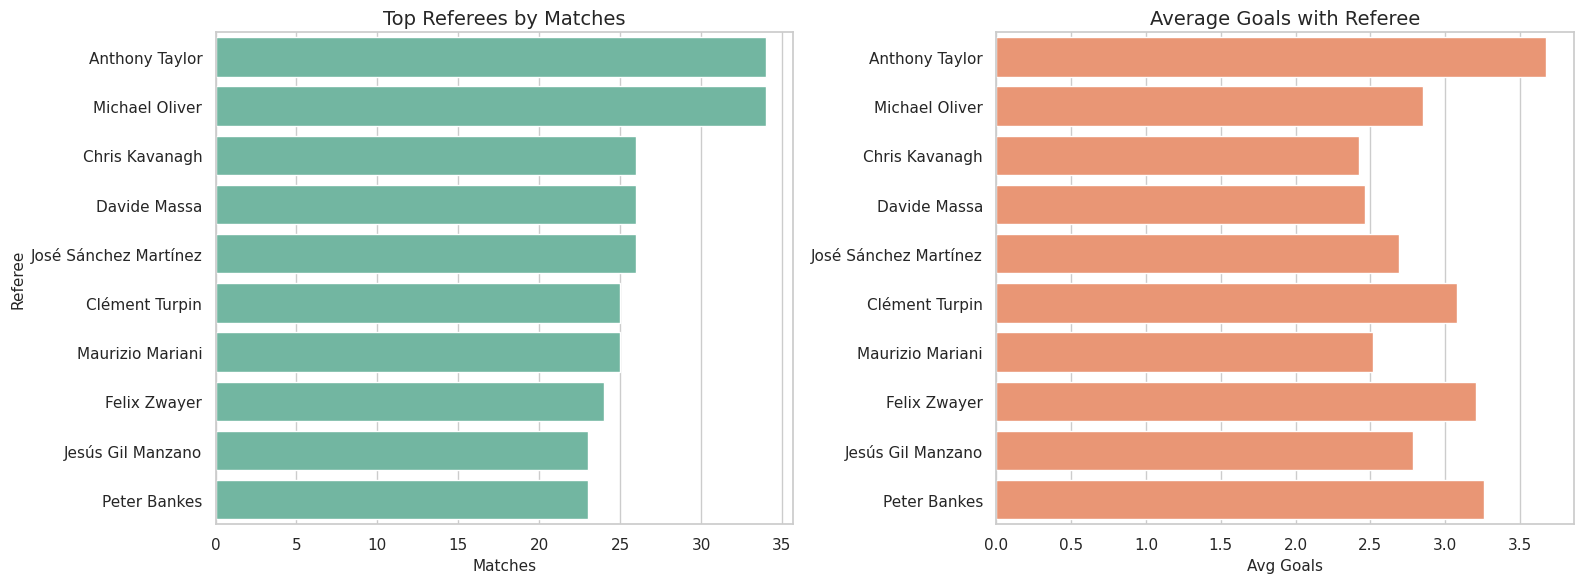

In [26]:
top_refs = df["referee"].value_counts().head(10).index
ref_stats = (df[df["referee"].isin(top_refs)]
             .groupby("referee")
             .agg(matches=("match_outcome","count"),
                  avg_goals=("TotalGoals","mean"))
             .sort_values("matches", ascending=False))

fig, ax = plt.subplots(1,2, figsize=(16,6))
sns.barplot(x=ref_stats["matches"].values, y=ref_stats.index, ax=ax[0], color=PRIMARY_COLOR)
ax[0].set_title("Top Referees by Matches"); ax[0].set_xlabel("Matches"); ax[0].set_ylabel("Referee")

sns.barplot(x=ref_stats["avg_goals"].values, y=ref_stats.index, ax=ax[1], color=SECONDARY_COLOR)
ax[1].set_title("Average Goals with Referee"); ax[1].set_xlabel("Avg Goals"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()


## Goal Difference by Outcome

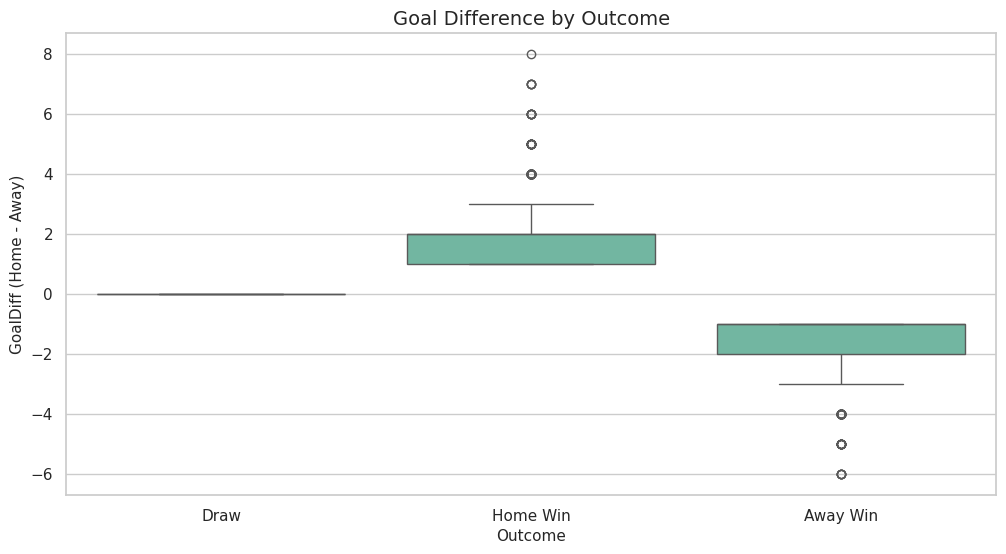

In [27]:
sns.boxplot(data=df, x="match_outcome", y="GoalDiff", color=PRIMARY_COLOR)
plt.title("Goal Difference by Outcome"); plt.xlabel("Outcome"); plt.ylabel("GoalDiff (Home - Away)")
plt.show()


## Home vs Away goals

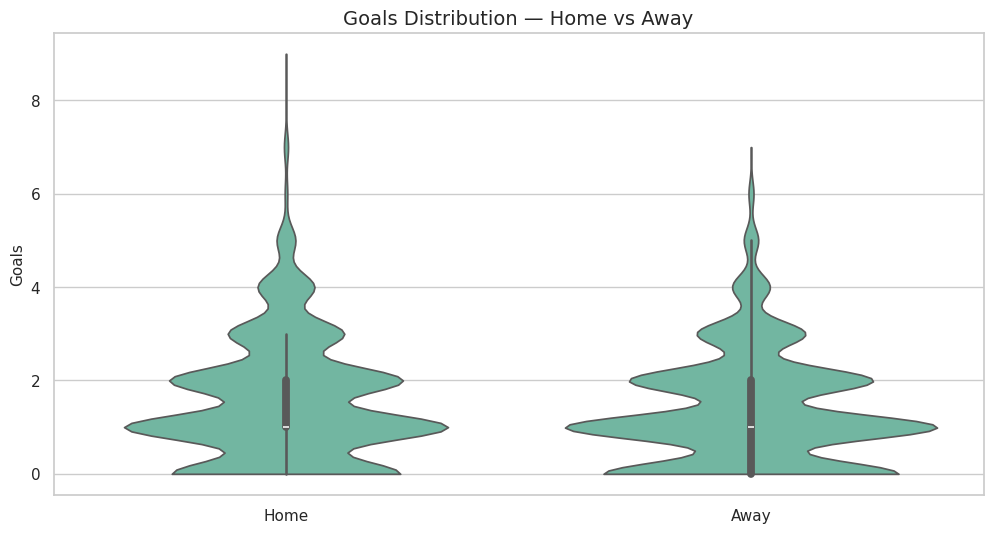

In [28]:
goals_melt = pd.melt(
    df[["fulltime_home","fulltime_away"]],
    value_vars=["fulltime_home","fulltime_away"],
    var_name="side", value_name="goals"
).replace({"fulltime_home": "Home", "fulltime_away": "Away"})
sns.violinplot(data=goals_melt, x="side", y="goals", inner="box", cut=0, color=PRIMARY_COLOR)
plt.title("Goals Distribution — Home vs Away"); plt.xlabel(""); plt.ylabel("Goals")
plt.show()

## Clean Sheets

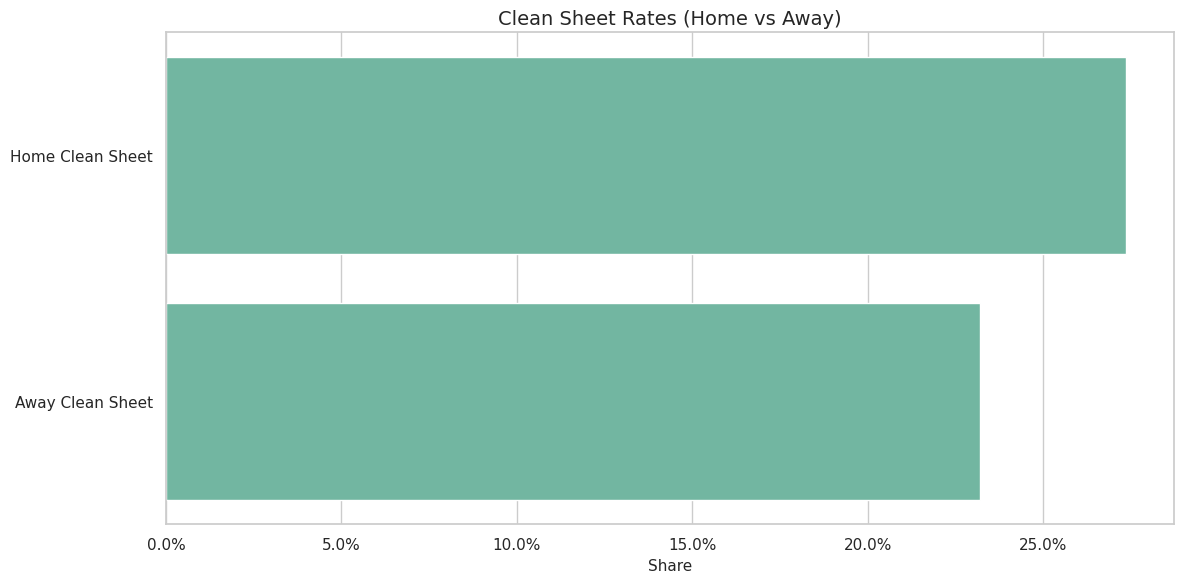

In [29]:
cs_rates = pd.DataFrame({
    "Home Clean Sheet": [df["home_cs"].mean()],
    "Away Clean Sheet": [df["away_cs"].mean()]
}).T.rename(columns={0:"rate"}).sort_values("rate", ascending=False)

ax = sns.barplot(x=cs_rates["rate"].values, y=cs_rates.index, color=PRIMARY_COLOR)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.title("Clean Sheet Rates (Home vs Away)")
plt.xlabel("Share"); plt.ylabel("")
plt.tight_layout(); plt.show()


## Clean Sheet Rates by Competition (Home vs Away)

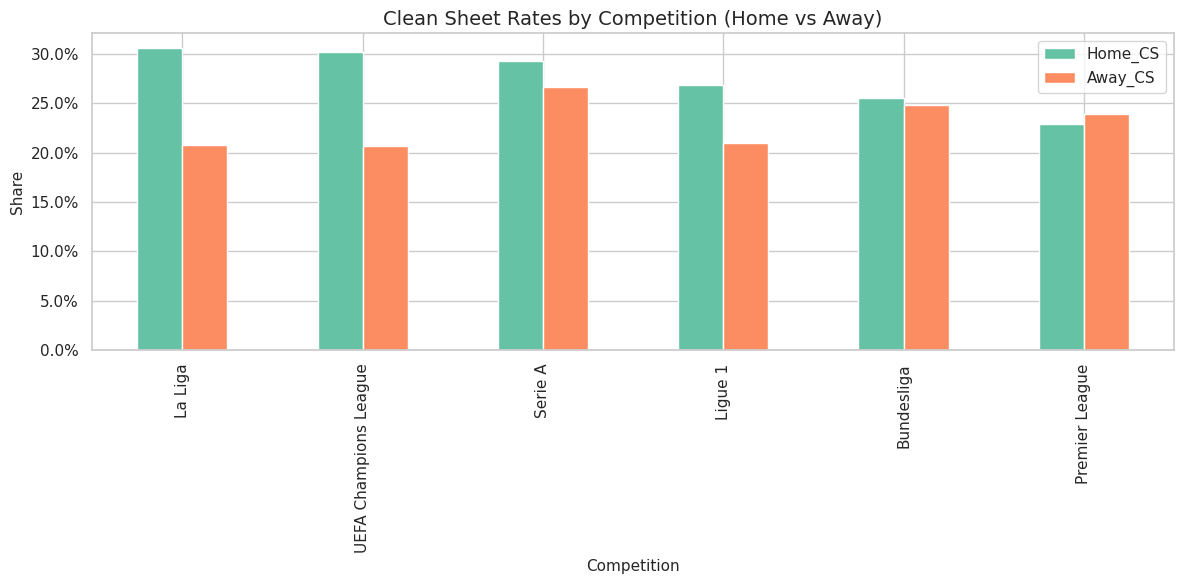

In [30]:
cs_comp = (df.groupby("competition_name")
          .agg(Home_CS=("home_cs","mean"), Away_CS=("away_cs","mean"))
          .sort_values("Home_CS", ascending=False))

ax = cs_comp.plot(kind="bar", figsize=(12,6))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title("Clean Sheet Rates by Competition (Home vs Away)")
plt.ylabel("Share"); plt.xlabel("Competition")
plt.tight_layout(); plt.show()


## Comeback Rate After Half-time

Full comebacks: 17.1% | Salvaged draws from behind: 10.9%


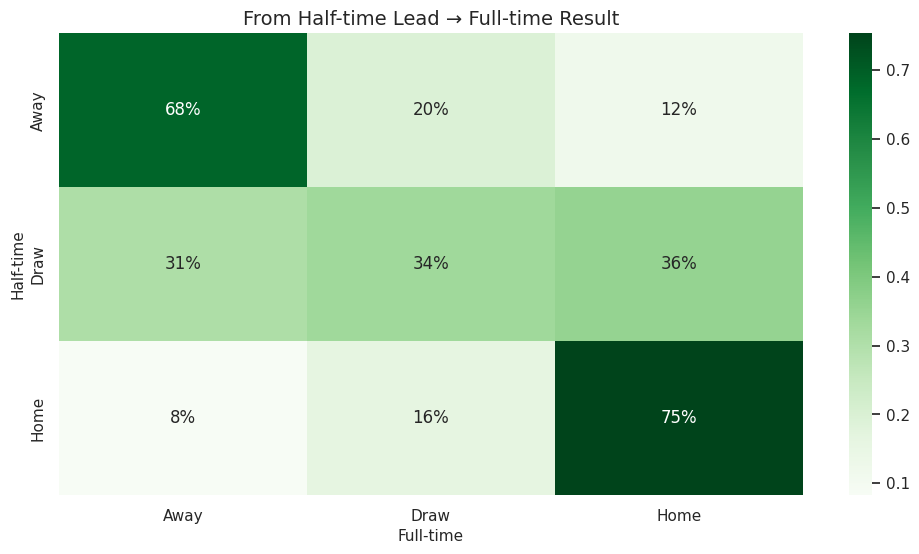

In [31]:
if {"halftime_home","halftime_away"}.issubset(df.columns):
    # Drop rows missing HT info for this analysis only
    ht = df.dropna(subset=["halftime_home","halftime_away"]).copy()
    lead_ht = np.sign(ht["halftime_home"] - ht["halftime_away"]).map({1:"Home",-1:"Away",0:"Draw"})
    lead_ft = np.sign(ht["fulltime_home"] - ht["fulltime_away"]).map({1:"Home",-1:"Away",0:"Draw"})
    tmp = pd.DataFrame({"lead_ht":lead_ht, "lead_ft":lead_ft})

    comeback = ((tmp["lead_ht"].isin(["Home","Away"])) & (tmp["lead_ht"] != tmp["lead_ft"])).mean()
    draw_from_behind = ((tmp["lead_ht"].isin(["Home","Away"])) & (tmp["lead_ft"]=="Draw")).mean()
    print(f"Full comebacks: {comeback:.1%} | Salvaged draws from behind: {draw_from_behind:.1%}")

    tab = pd.crosstab(tmp["lead_ht"], tmp["lead_ft"], normalize="index").fillna(0)
    sns.heatmap(tab, annot=True, fmt=".0%", cmap="Greens")
    plt.title("From Half-time Lead → Full-time Result"); plt.xlabel("Full-time"); plt.ylabel("Half-time")
    plt.show()

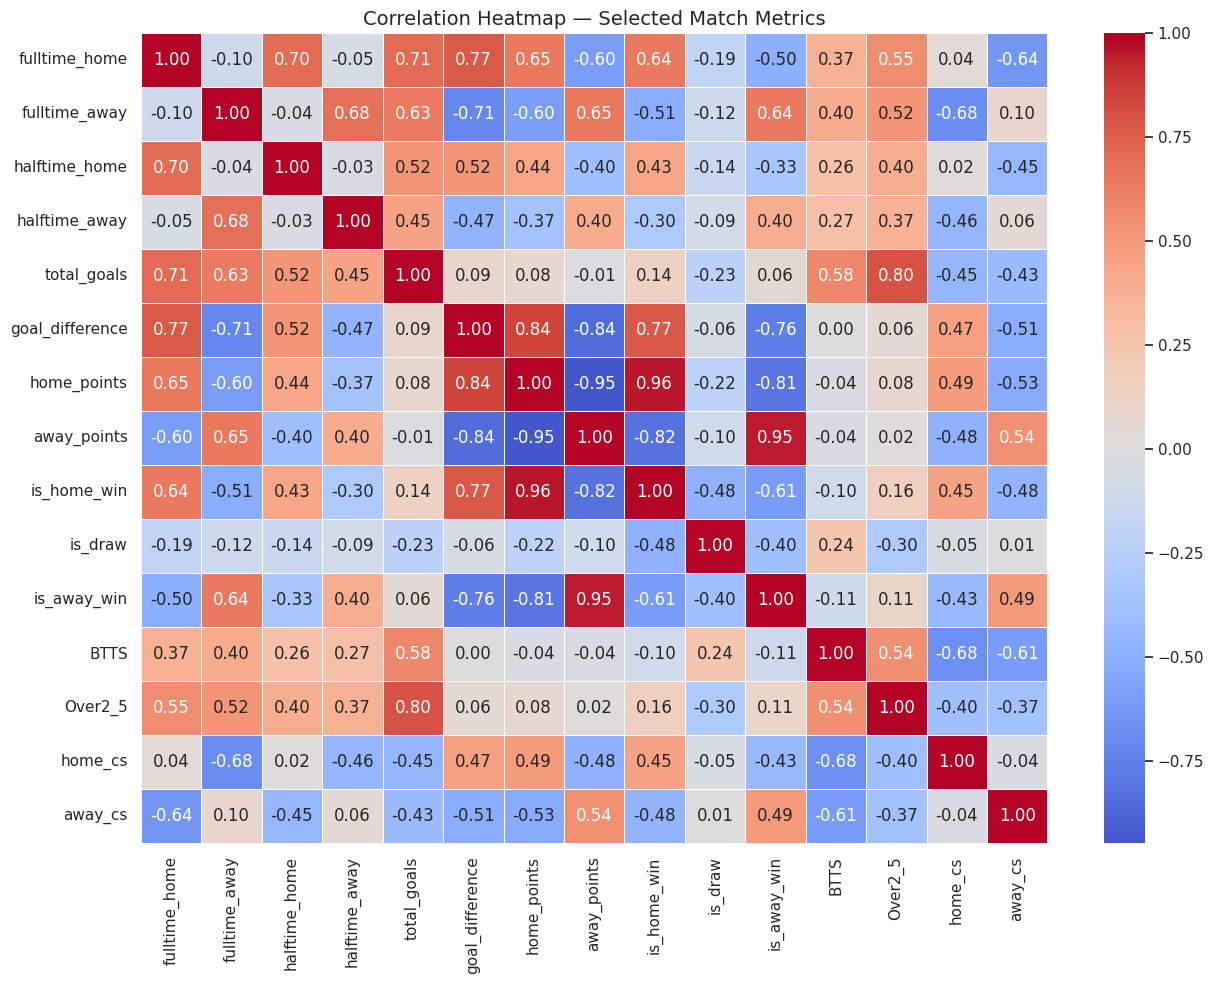

In [32]:
corr_columns = [
    "fulltime_home",
    "fulltime_away",
    "halftime_home",
    "halftime_away",
    "total_goals",
    "goal_difference",
    "home_points",
    "away_points",
    "is_home_win",
    "is_draw",
    "is_away_win",
    "BTTS",
    "Over2_5",
    "home_cs",
    "away_cs",
]

corr_columns = [column for column in corr_columns if column in df.columns]
corr = df[corr_columns].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap — Selected Match Metrics")
plt.tight_layout()
plt.show()


## Key Takeaways

- The dataset contains **1,941 matches** across **6 competitions** and **110 teams**.
- The overall scoring level is high, with approximately **2.88 goals per match**.
- Home teams won approximately **42.9%** of matches, compared with **33.3%** away wins and **23.9%** draws.
- BTTS occurred in approximately **55.1%** of matches, while Over 2.5 goals occurred in approximately **54.6%** of matches.
- UEFA Champions League had the highest average scoring profile in this dataset, with approximately **3.33 goals per match**.
- Team comparisons are more reliable when normalized per match, because teams do not always play the same number of matches across competitions.
- The notebook is best treated as an exploratory and dashboard-ready analysis, not a predictive modeling workflow. Match-result prediction would require pre-match features to avoid leakage.

## Suggested Next Steps

- Build a small dashboard from the competition, team, and time-based summaries.
- Add pre-match features such as form, rest days, injuries, odds, or Elo ratings before attempting prediction.
- Track scoring and outcome metrics over time to monitor tactical or competition-level changes.
